# 02 - Entrenamiento del Modelo de Clasificación de Intents

Entrenamos un modelo de clasificación de texto usando **spaCy TextCategorizer** para predecir intents a partir de mensajes de usuarios.

## ¿Qué haremos?
1. Cargar y preparar los datos de entrenamiento
2. Configurar el pipeline de spaCy con TextCategorizer
3. Dividir datos en entrenamiento y validación
4. Entrenar el modelo
5. Evaluar resultados preliminares
6. Guardar el modelo entrenado

## 1. Importar librerías

Usamos spaCy para el modelo de NLP y sklearn para dividir los datos.

In [1]:
import spacy
from spacy.training import Example
from spacy.util import minibatch, compounding
import json
import random
from pathlib import Path
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Verificar versión de spaCy
print(f"✅ spaCy versión: {spacy.__version__}")
print(f"✅ Librerías cargadas correctamente")

✅ spaCy versión: 3.8.11
✅ Librerías cargadas correctamente


## 2. Cargar datos de entrenamiento

Cargamos el archivo `intents.jsonl` y lo convertimos al formato que espera spaCy TextCategorizer.

In [2]:
# Cargar datos desde intents.jsonl
data = []
with open('../data/intents.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            data.append(json.loads(line))

# Obtener todas las etiquetas únicas
all_labels = list(set([item['label'] for item in data]))
print(f"📊 Datos cargados:")
print(f"   Total de ejemplos: {len(data)}")
print(f"   Total de intents (clases): {len(all_labels)}")
print(f"\n🏷️ Intents: {sorted(all_labels)}")

📊 Datos cargados:
   Total de ejemplos: 479
   Total de intents (clases): 22

🏷️ Intents: ['agradecimiento', 'app_movil', 'cancelar_pedido', 'confirmar_pedido', 'consultar_horario', 'consultar_menu', 'consultar_precio', 'consultar_ubicacion', 'delivery', 'despedida', 'fallback', 'hablar_humano', 'info_empresa', 'metodos_pago', 'modificar_pedido', 'opinion_comida', 'queja', 'realizar_pedido', 'reservacion', 'retiro_local', 'saludo', 'trabajo']


## 3. Convertir al formato de spaCy

spaCy TextCategorizer requiere que cada ejemplo tenga un diccionario de categorías donde la categoría correcta tiene valor `True` y las demás `False`.

In [3]:
def convert_to_spacy_format(data, all_labels):
    """
    Convierte los datos al formato que espera spaCy TextCategorizer.
    Formato: (texto, {"cats": {"label1": True/False, "label2": True/False, ...}})
    """
    spacy_data = []
    for item in data:
        text = item['text']
        label = item['label']
        # Crear diccionario de categorías (True para la correcta, False para las demás)
        cats = {l: (l == label) for l in all_labels}
        spacy_data.append((text, {"cats": cats}))
    return spacy_data

# Convertir datos
spacy_data = convert_to_spacy_format(data, all_labels)

# Mostrar ejemplo de formato
print("📝 Ejemplo del formato de spaCy:")
print(f"\nTexto: \"{spacy_data[0][0]}\"")
print(f"Categorías: {spacy_data[0][1]}")

📝 Ejemplo del formato de spaCy:

Texto: "hola"
Categorías: {'cats': {'delivery': False, 'realizar_pedido': False, 'consultar_precio': False, 'retiro_local': False, 'queja': False, 'app_movil': False, 'modificar_pedido': False, 'reservacion': False, 'consultar_horario': False, 'agradecimiento': False, 'cancelar_pedido': False, 'confirmar_pedido': False, 'fallback': False, 'info_empresa': False, 'despedida': False, 'opinion_comida': False, 'metodos_pago': False, 'saludo': True, 'consultar_menu': False, 'hablar_humano': False, 'consultar_ubicacion': False, 'trabajo': False}}


## 4. Dividir datos en entrenamiento y validación

Usamos 80% para entrenamiento y 20% para validación. 
La estratificación asegura que cada clase esté representada proporcionalmente en ambos conjuntos.

In [4]:
# Obtener etiquetas para estratificación
labels_for_split = [item['label'] for item in data]

# Dividir datos (80% train, 20% validation)
train_data, val_data = train_test_split(
    spacy_data, 
    test_size=0.2, 
    random_state=42,
    stratify=labels_for_split
)

print(f"📊 División de datos:")
print(f"   Entrenamiento: {len(train_data)} ejemplos ({len(train_data)/len(spacy_data)*100:.1f}%)")
print(f"   Validación: {len(val_data)} ejemplos ({len(val_data)/len(spacy_data)*100:.1f}%)")

📊 División de datos:
   Entrenamiento: 383 ejemplos (80.0%)
   Validación: 96 ejemplos (20.0%)


## 5. Crear modelo spaCy con TextCategorizer

Cargamos el modelo base en español (`es_core_news_sm`) y agregamos el componente `textcat_multilabel` para clasificación de texto.

**¿Por qué `textcat_multilabel`?** Aunque nuestro problema es de una sola etiqueta por texto, este componente es más robusto y permite manejar casos ambiguos donde el modelo no está seguro.

In [5]:
# Cargar modelo base en español
nlp = spacy.load("es_core_news_sm")

# Agregar TextCategorizer al pipeline
if "textcat_multilabel" not in nlp.pipe_names:
    textcat = nlp.add_pipe("textcat_multilabel", last=True)
else:
    textcat = nlp.get_pipe("textcat_multilabel")

# Agregar las etiquetas (intents) al clasificador
for label in all_labels:
    textcat.add_label(label)

print(f"✅ Modelo creado con TextCategorizer")
print(f"📋 Pipeline: {nlp.pipe_names}")
print(f"🏷️ Etiquetas agregadas: {len(all_labels)}")

✅ Modelo creado con TextCategorizer
📋 Pipeline: ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner', 'textcat_multilabel']
🏷️ Etiquetas agregadas: 22


## 6. Configurar parámetros de entrenamiento

Definimos:
- **Epochs**: Número de veces que el modelo verá todos los datos (30 iteraciones)
- **Batch size**: Tamaño de lotes que aumenta progresivamente (4 → 32)
- **Dropout**: Regularización para evitar overfitting (0.2 = 20%)

In [6]:
# Parámetros de entrenamiento
N_EPOCHS = 30           # Número de iteraciones sobre todo el dataset
DROPOUT = 0.2           # Dropout para regularización
BATCH_SIZE_START = 4    # Tamaño inicial de batch
BATCH_SIZE_END = 32     # Tamaño final de batch

print(f"⚙️ Configuración de entrenamiento:")
print(f"   Epochs: {N_EPOCHS}")
print(f"   Dropout: {DROPOUT}")
print(f"   Batch size: {BATCH_SIZE_START} → {BATCH_SIZE_END}")

⚙️ Configuración de entrenamiento:
   Epochs: 30
   Dropout: 0.2
   Batch size: 4 → 32


## 7. Entrenar el modelo

El proceso de entrenamiento:
1. Solo entrenamos el componente `textcat_multilabel` (no tocamos ner, parser, etc.)
2. En cada epoch: mezclamos datos, creamos batches, actualizamos pesos
3. Mostramos el progreso cada 5 epochs

In [7]:
# Obtener solo el componente de textcat para entrenamiento
pipe_exceptions = ["textcat_multilabel"]
other_pipes = [pipe for pipe in nlp.pipe_names if pipe not in pipe_exceptions]

# Entrenar solo el textcat, deshabilitando los demás componentes
losses_history = []

print("🚀 Iniciando entrenamiento...")
print("-" * 50)

with nlp.disable_pipes(*other_pipes):
    optimizer = nlp.begin_training()
    
    for epoch in range(N_EPOCHS):
        random.shuffle(train_data)
        losses = {}
        
        # Crear batches con tamaño creciente
        batches = minibatch(train_data, size=compounding(BATCH_SIZE_START, BATCH_SIZE_END, 1.001))
        
        for batch in batches:
            examples = []
            for text, annotations in batch:
                doc = nlp.make_doc(text)
                examples.append(Example.from_dict(doc, annotations))
            
            nlp.update(examples, sgd=optimizer, drop=DROPOUT, losses=losses)
        
        losses_history.append(losses.get("textcat_multilabel", 0))
        
        # Mostrar progreso cada 5 epochs
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"   Epoch {epoch + 1:2d}/{N_EPOCHS} - Loss: {losses.get('textcat_multilabel', 0):.4f}")

print("-" * 50)
print("✅ Entrenamiento completado!")

🚀 Iniciando entrenamiento...
--------------------------------------------------
   Epoch  1/30 - Loss: 8.9029
   Epoch  5/30 - Loss: 2.5598
   Epoch 10/30 - Loss: 1.2373
   Epoch 15/30 - Loss: 0.7037
   Epoch 20/30 - Loss: 0.5364
   Epoch 25/30 - Loss: 0.3489
   Epoch 30/30 - Loss: 0.2318
--------------------------------------------------
✅ Entrenamiento completado!


## 8. Visualizar curva de pérdida

La pérdida (loss) debe disminuir con cada epoch. Si sube o se estanca, puede indicar problemas de entrenamiento.

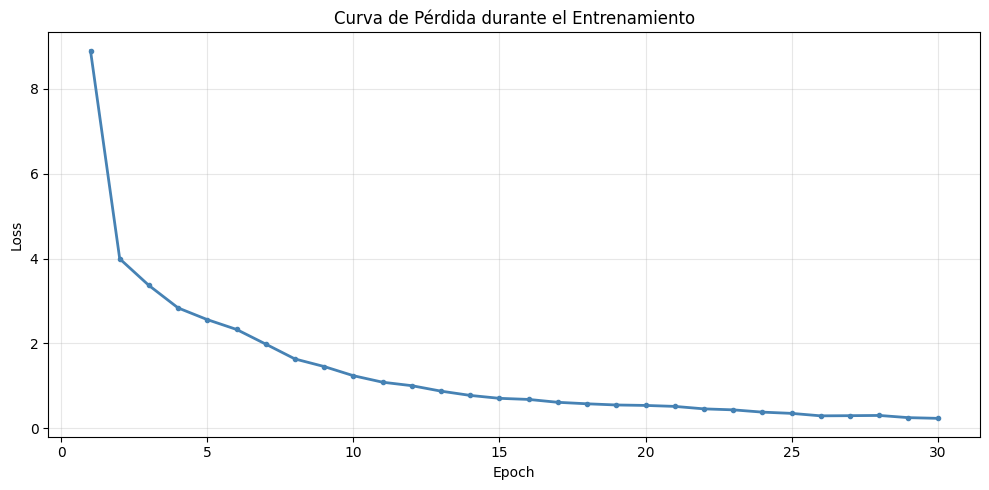


📉 Loss inicial: 8.9029
📉 Loss final: 0.2318
📉 Reducción: 97.4%


In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, N_EPOCHS + 1), losses_history, marker='o', markersize=3, linewidth=2, color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Curva de Pérdida durante el Entrenamiento')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📉 Loss inicial: {losses_history[0]:.4f}")
print(f"📉 Loss final: {losses_history[-1]:.4f}")
print(f"📉 Reducción: {((losses_history[0] - losses_history[-1]) / losses_history[0] * 100):.1f}%")

## 9. Evaluación preliminar en datos de validación

Probamos el modelo con los datos de validación para ver qué tan bien clasifica.
Calculamos accuracy (porcentaje de predicciones correctas).

In [9]:
def evaluate_model(nlp, data):
    """Evalúa el modelo y retorna accuracy y predicciones"""
    correct = 0
    total = len(data)
    predictions = []
    
    for text, annotations in data:
        doc = nlp(text)
        # Obtener la categoría con mayor probabilidad
        predicted = max(doc.cats, key=doc.cats.get)
        # Obtener la categoría real
        actual = [k for k, v in annotations['cats'].items() if v][0]
        
        predictions.append({
            'text': text,
            'actual': actual,
            'predicted': predicted,
            'confidence': doc.cats[predicted],
            'correct': predicted == actual
        })
        
        if predicted == actual:
            correct += 1
    
    accuracy = correct / total
    return accuracy, predictions

# Evaluar en datos de validación
val_accuracy, val_predictions = evaluate_model(nlp, val_data)

print(f"📊 Evaluación en datos de validación:")
print(f"   Accuracy: {val_accuracy:.2%}")
print(f"   Correctos: {sum(1 for p in val_predictions if p['correct'])}/{len(val_predictions)}")

📊 Evaluación en datos de validación:
   Accuracy: 60.42%
   Correctos: 58/96


## 10. Análisis de errores

Veamos qué ejemplos clasificó mal el modelo para entender dónde necesita mejorar.

In [10]:
# Mostrar predicciones incorrectas
errores = [p for p in val_predictions if not p['correct']]

if len(errores) > 0:
    print(f"❌ Predicciones incorrectas ({len(errores)}):\n")
    for i, e in enumerate(errores[:15], 1):  # Mostrar máximo 15
        print(f"{i}. \"{e['text']}\"")
        print(f"   Real: {e['actual']} | Predicho: {e['predicted']} (conf: {e['confidence']:.2%})\n")
    
    if len(errores) > 15:
        print(f"   ... y {len(errores) - 15} errores más")
else:
    print("✅ ¡No hay predicciones incorrectas!")

❌ Predicciones incorrectas (38):

1. "horarios de atencion"
   Real: consultar_horario | Predicho: hablar_humano (conf: 61.74%)

2. "deme una humita"
   Real: realizar_pedido | Predicho: hablar_humano (conf: 2.33%)

3. "quiero agregar chorizo"
   Real: realizar_pedido | Predicho: modificar_pedido (conf: 99.48%)

4. "pago contra entrega"
   Real: metodos_pago | Predicho: delivery (conf: 76.47%)

5. "quiero trabajar con ustedes"
   Real: trabajo | Predicho: realizar_pedido (conf: 51.02%)

6. "tienen app"
   Real: app_movil | Predicho: reservacion (conf: 0.12%)

7. "ya no lo quiero"
   Real: cancelar_pedido | Predicho: opinion_comida (conf: 77.01%)

8. "tienen repartidor"
   Real: delivery | Predicho: reservacion (conf: 97.75%)

9. "horario portal shopping"
   Real: consultar_horario | Predicho: consultar_ubicacion (conf: 56.80%)

10. "quisiera ordenar comida"
   Real: realizar_pedido | Predicho: modificar_pedido (conf: 5.57%)

11. "mandeme la ubicacion por favor"
   Real: consultar_ubica

## 11. Probar el modelo con ejemplos nuevos

Probemos el modelo con mensajes que podrían llegar de usuarios reales.

In [11]:
def predict_intent(text):
    """Predice el intent de un texto y muestra las probabilidades"""
    doc = nlp(text)
    # Ordenar por probabilidad
    sorted_cats = sorted(doc.cats.items(), key=lambda x: x[1], reverse=True)
    top_intent = sorted_cats[0]
    return top_intent[0], top_intent[1], sorted_cats[:3]

# Ejemplos de prueba (mensajes que podrían enviar usuarios reales)
test_messages = [
    "hola buenas tardes",
    "cuanto cuesta el hornado",
    "quiero pedir un mote para llevar",
    "donde estan ubicados",
    "a que hora cierran hoy",
    "muchas gracias por la ayuda",
    "ya no quiero el pedido",
    "cual es el clima hoy",
    "tienen local en el condado",
    "quiero agregar una bebida a mi pedido"
]

print("🧪 Prueba del modelo con mensajes nuevos:\n")
print("-" * 70)
for msg in test_messages:
    intent, conf, top3 = predict_intent(msg)
    print(f"📝 \"{msg}\"")
    print(f"   ➡️  Intent: {intent} (confianza: {conf:.1%})")
    print(f"   📊 Top 3: {', '.join([f'{i[0]}:{i[1]:.0%}' for i in top3])}")
    print("-" * 70)

🧪 Prueba del modelo con mensajes nuevos:

----------------------------------------------------------------------
📝 "hola buenas tardes"
   ➡️  Intent: saludo (confianza: 100.0%)
   📊 Top 3: saludo:100%, delivery:0%, consultar_ubicacion:0%
----------------------------------------------------------------------
📝 "cuanto cuesta el hornado"
   ➡️  Intent: consultar_precio (confianza: 100.0%)
   📊 Top 3: consultar_precio:100%, delivery:0%, info_empresa:0%
----------------------------------------------------------------------
📝 "quiero pedir un mote para llevar"
   ➡️  Intent: realizar_pedido (confianza: 100.0%)
   📊 Top 3: realizar_pedido:100%, queja:0%, modificar_pedido:0%
----------------------------------------------------------------------
📝 "donde estan ubicados"
   ➡️  Intent: consultar_ubicacion (confianza: 100.0%)
   📊 Top 3: consultar_ubicacion:100%, realizar_pedido:1%, delivery:1%
----------------------------------------------------------------------
📝 "a que hora cierran hoy"
   

## 12. Guardar el modelo entrenado

Guardamos el modelo en la carpeta `models/intent_classifier/` para usarlo en el servicio de IA del chatbot.

In [12]:
# Ruta donde guardar el modelo
model_path = Path("../models/intent_classifier")

# Crear directorio si no existe
model_path.mkdir(parents=True, exist_ok=True)

# Guardar el modelo
nlp.to_disk(model_path)

print(f"✅ Modelo guardado exitosamente en: {model_path.absolute()}")
print(f"\n📁 Contenido del directorio:")
for item in model_path.iterdir():
    print(f"   - {item.name}")

✅ Modelo guardado exitosamente en: c:\Users\USUARIO\Desktop\PYTHON\los_motes_webhook\notebooks\..\models\intent_classifier

📁 Contenido del directorio:
   - .gitkeep
   - attribute_ruler
   - config.cfg
   - lemmatizer
   - meta.json
   - morphologizer
   - ner
   - parser
   - senter
   - textcat_multilabel
   - tok2vec
   - tokenizer
   - vocab


## 13. Verificar que el modelo carga correctamente

Cargamos el modelo guardado para verificar que funciona correctamente.

In [13]:
# Cargar modelo guardado
nlp_loaded = spacy.load(model_path)

# Probar con un mensaje
test_msg = "hola quiero pedir un hornado"
doc = nlp_loaded(test_msg)

# Obtener predicción
predicted = max(doc.cats, key=doc.cats.get)
confidence = doc.cats[predicted]

print(f"✅ Modelo cargado correctamente desde: {model_path}")
print(f"\n🧪 Prueba de verificación:")
print(f"   Mensaje: \"{test_msg}\"")
print(f"   Intent predicho: {predicted}")
print(f"   Confianza: {confidence:.1%}")

✅ Modelo cargado correctamente desde: ..\models\intent_classifier

🧪 Prueba de verificación:
   Mensaje: "hola quiero pedir un hornado"
   Intent predicho: saludo
   Confianza: 86.8%


## 14. Resumen del entrenamiento

Resumen final con las métricas y la ruta del modelo guardado.

In [14]:
# Resumen final
print("=" * 60)
print("📊 RESUMEN DEL ENTRENAMIENTO")
print("=" * 60)

print(f"\n📈 Datos:")
print(f"   • Total de ejemplos: {len(data)}")
print(f"   • Entrenamiento: {len(train_data)}")
print(f"   • Validación: {len(val_data)}")
print(f"   • Número de intents: {len(all_labels)}")

print(f"\n⚙️ Configuración:")
print(f"   • Epochs: {N_EPOCHS}")
print(f"   • Dropout: {DROPOUT}")
print(f"   • Modelo base: es_core_news_sm")

print(f"\n📉 Resultados:")
print(f"   • Loss inicial: {losses_history[0]:.4f}")
print(f"   • Loss final: {losses_history[-1]:.4f}")
print(f"   • Accuracy en validación: {val_accuracy:.2%}")
print(f"   • Errores en validación: {len(errores)}")

print(f"\n💾 Modelo guardado:")
print(f"   • Ruta: {model_path.absolute()}")

print("\n" + "=" * 60)
print("✅ ENTRENAMIENTO COMPLETADO")
print("=" * 60)
print("\n➡️ Siguientes pasos:")
print("   1. Ejecutar 03_evaluacion_metricas.ipynb para métricas detalladas")
print("   2. Implementar services/intent_classifier.py")
print("   3. Integrar con services/ai_service.py")
print("=" * 60)

📊 RESUMEN DEL ENTRENAMIENTO

📈 Datos:
   • Total de ejemplos: 479
   • Entrenamiento: 383
   • Validación: 96
   • Número de intents: 22

⚙️ Configuración:
   • Epochs: 30
   • Dropout: 0.2
   • Modelo base: es_core_news_sm

📉 Resultados:
   • Loss inicial: 8.9029
   • Loss final: 0.2318
   • Accuracy en validación: 60.42%
   • Errores en validación: 38

💾 Modelo guardado:
   • Ruta: c:\Users\USUARIO\Desktop\PYTHON\los_motes_webhook\notebooks\..\models\intent_classifier

✅ ENTRENAMIENTO COMPLETADO

➡️ Siguientes pasos:
   1. Ejecutar 03_evaluacion_metricas.ipynb para métricas detalladas
   2. Implementar services/intent_classifier.py
   3. Integrar con services/ai_service.py
